In [83]:
# 타이타닉 데이터에 RandomForest, XGBoost, LightGBM 적용 후 ROC_AUC 비교하기

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [84]:
df = titanic.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [85]:
# survived <- target
# sibsp : 동반탑승객 수
# embark_town, alive(survived와 중복), who(sex와 중복), deck(결측치가 너무 많음) < drop 

df = df.drop(["embark_town", "alive", "who", "deck"], axis = 1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,True


In [86]:
# sex -> 남자:1, 여자:0
# embarked -> C = 1, S = 2, Q = 3
# class -> First = 1, Second = 2, Third = 3
# adult_male -> True = 1, False = 0
# alone -> True = 1, False = 0

df["sex"] = df["sex"].map({
    "male": 1,
    "female": 0
})

df["embarked"] = df["embarked"].map({
    "C": 1,
    "S": 2,
    "Q": 3
})

df["class"] = df["class"].map({
    "First": 1,
    "Second": 2,
    "Third": 3
})

df["adult_male"] = df["adult_male"].map({
    True: 1,
    False: 0
})

df["alone"] = df["alone"].map({
    True: 1,
    False: 0
})

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,alone
0,0,3,1,22.0,1,0,7.2500,2.0,3,1,0
1,1,1,0,38.0,1,0,71.2833,1.0,1,0,0
2,1,3,0,26.0,0,0,7.9250,2.0,3,0,1
3,1,1,0,35.0,1,0,53.1000,2.0,1,0,0
4,0,3,1,35.0,0,0,8.0500,2.0,3,1,1


In [87]:
df.info()
df["embarked"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    int64   
 3   age         714 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    889 non-null    float64 
 8   class       891 non-null    category
 9   adult_male  891 non-null    int64   
 10  alone       891 non-null    int64   
dtypes: category(1), float64(3), int64(7)
memory usage: 70.6 KB


embarked
2.0    644
1.0    168
3.0     77
Name: count, dtype: int64

In [88]:
# age 결측치 -> mean으로 채우기
# embark 결측치 -> 최빈값으로 채우기

df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(2)

# X, y 나누기

X_features = df.iloc[:, 1:]
y_label = df.iloc[:, 0]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size = 0.2, random_state = 42)

In [104]:
# 평가 지표 살펴보기
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)

    print("Confusion matrix:", confusion)
    print("정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}".format(accuracy, precision, recall, f1, roc_auc))

    return roc_auc

In [106]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# RandomForest
rf_clf = RandomForestClassifier(random_state = 42)

rf_clf.fit(X_train, y_train)

rf_pred = rf_clf.predict(X_test)
rf_pred_prob = rf_clf.predict_proba(X_test)[:, 1]

# randomforest 지표 보기
print("RandomForest 결과")
rf_roc_auc = get_clf_eval(y_test, rf_pred, rf_pred_prob)

RandomForest 결과
Confusion matrix: [[92 13]
 [19 55]]
정확도: 0.8212, 정밀도: 0.8088, 재현율: 0.7432, F1: 0.7746, AUC: 0.8859


In [ ]:
# XGBoost 수정하기..
xgb_clf = XGBClassifier(n_estimators = 400, learning_rate = 0.05, early_stopping_rounds = 50, eval_metric = "auc", verbose = 1)

xgb_clf.fit(X_tr, y_tr, eval_set = [(X_tr, y_tr), (X_val, y_val)])

lgbm_pred = lgbm_clf.predict(X_test)
lgbm_pred_prob = lgbm_clf.predict_proba(X_test)[:, 1]

print("LightGBM 결과")
get_clf_eval(y_test, lgbm_pred, lgbm_pred_prob)

[0]	validation_0-auc:0.87977	validation_1-auc:0.89524
[1]	validation_0-auc:0.87977	validation_1-auc:0.89524
[2]	validation_0-auc:0.87977	validation_1-auc:0.89524
[3]	validation_0-auc:0.87977	validation_1-auc:0.89524
[4]	validation_0-auc:0.87977	validation_1-auc:0.89524
[5]	validation_0-auc:0.87977	validation_1-auc:0.89524
[6]	validation_0-auc:0.87977	validation_1-auc:0.89524
[7]	validation_0-auc:0.87977	validation_1-auc:0.89524
[8]	validation_0-auc:0.87977	validation_1-auc:0.89524
[9]	validation_0-auc:0.88302	validation_1-auc:0.90238
[10]	validation_0-auc:0.88302	validation_1-auc:0.90238
[11]	validation_0-auc:0.88302	validation_1-auc:0.90238
[12]	validation_0-auc:0.88302	validation_1-auc:0.90238
[13]	validation_0-auc:0.88348	validation_1-auc:0.90556
[14]	validation_0-auc:0.88348	validation_1-auc:0.90556
[15]	validation_0-auc:0.88348	validation_1-auc:0.90556
[16]	validation_0-auc:0.88434	validation_1-auc:0.90556
[17]	validation_0-auc:0.88434	validation_1-auc:0.90556
[18]	validation_0-au

In [101]:
# LightGBM
lgbm_clf = LGBMClassifier(n_estimators = 400, learning_rate = 0.05, early_stopping_rounds = 50, eval_metric = "auc", verbose = 1)

lgbm_clf.fit(X_tr, y_tr, eval_set = [(X_tr, y_tr), (X_val, y_val)])

lgbm_pred = lgbm_clf.predict(X_test)
lgbm_pred_prob = lgbm_clf.predict_proba(X_test)[:, 1]

print("LightGBM 결과")
get_clf_eval(y_test, lgbm_pred, lgbm_pred_prob)

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Number of positive: 238, number of negative: 402
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 195
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 10
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.371875 -> initscore=-0.524181
[LightGBM] [Info] Start training from score -0.524181
[LightGBM] [Warning] No f

c:\Users\KDS-11\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


In [ ]:
# Before Optimization

print("=" * 15 + "Before Optimization AUC Score" + "=" * 15)
print()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

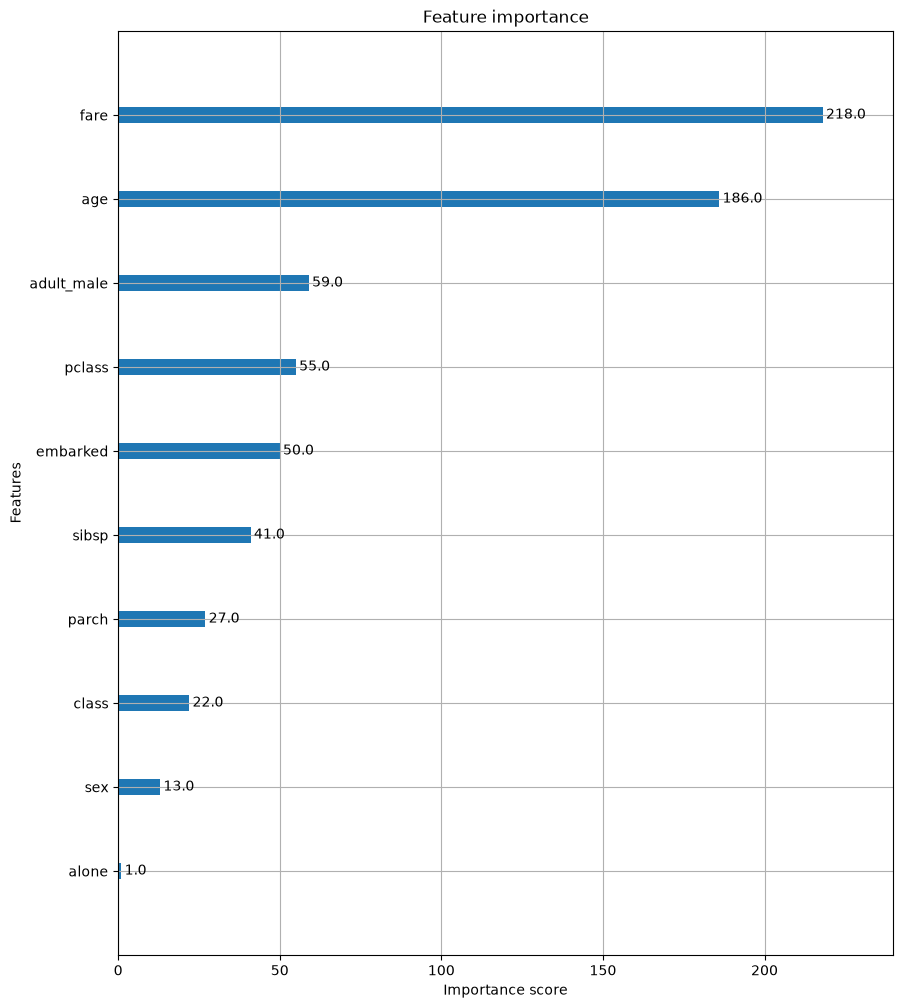

In [102]:
# Feature Importance 보기

# XGBoost
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_clf, ax = ax)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

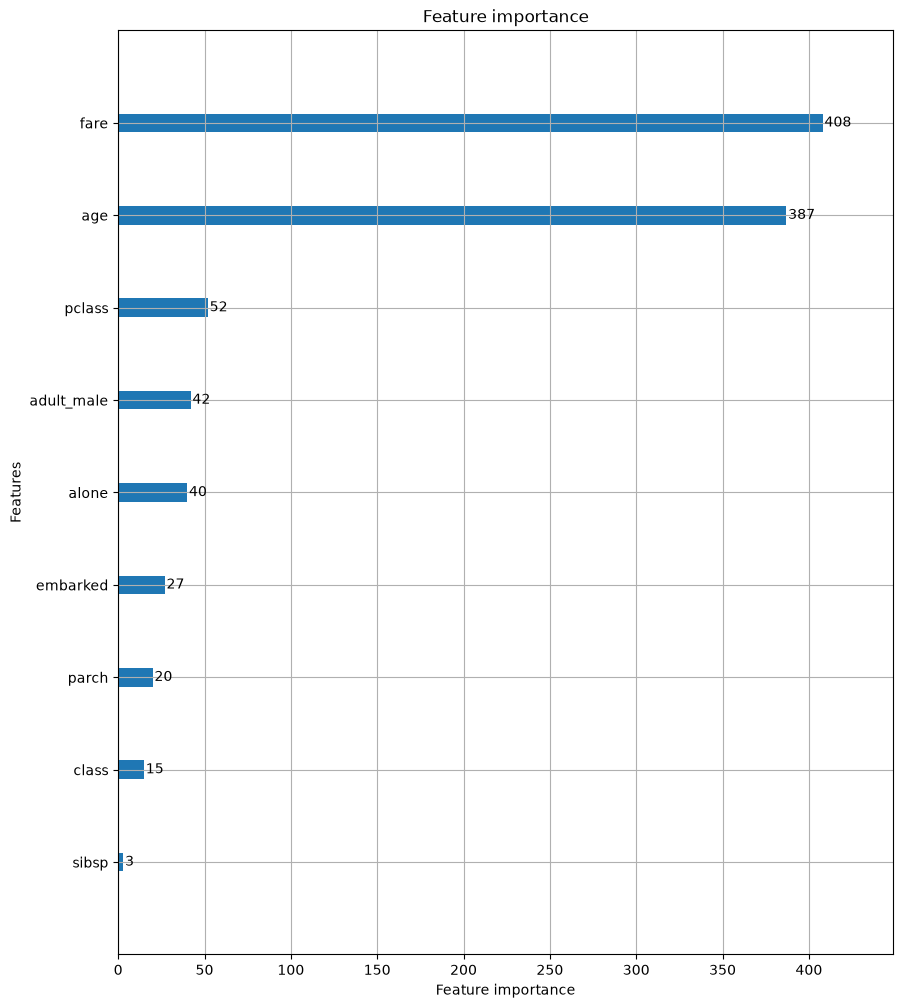

In [103]:
# LightGBM
from lightgbm import plot_importance

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_clf, ax = ax)